# PaSCient: supervised sample-level representations

[PaSCient](https://github.com/genentech/pascient) ([Rauer et al., 2024](https://arxiv.org/abs/2404.14413)) is a supervised deep learning method that learns patient-level representations from single-cell data. It uses a gene-to-cell encoder, attention-based cell-to-patient aggregation, and a patient encoder to produce fixed-size sample embeddings.

This notebook demonstrates how to use PaSCient through `patpy` on the COMBAT dataset.

## Setup

In [1]:
import pandas as pd
import scanpy as sc
import patpy
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

In [2]:
patpy.__version__

'0.14.0'

## Load and prepare data

We use the COMBAT dataset ([COMBAT Consortium, 2022](https://doi.org/10.1016/j.cell.2022.01.012)), available on [Kaggle](https://www.kaggle.com/datasets/vshitov/combat-covid-19-single-cell).

In [3]:
ADATA_PATH = "/home/icb/vladimir.shitov/projects/vladimir.shitov/2023_05_patient_representation_benchmark/reproducibility/pat_rep_benchmark/data/combat/combat_processed.h5ad"

In [4]:
adata = sc.read_h5ad(ADATA_PATH)
adata

AnnData object with n_obs × n_vars = 783677 × 3000
    obs: 'Annotation_cluster_id', 'Annotation_cluster_name', 'Annotation_minor_subset', 'Annotation_major_subset', 'Annotation_cell_type', 'GEX_region', 'QC_ngenes', 'QC_total_UMI', 'QC_pct_mitochondrial', 'QC_scrub_doublet_scores', 'TCR_chain_composition', 'TCR_clone_ID', 'TCR_clone_count', 'TCR_clone_proportion', 'TCR_contains_unproductive', 'TCR_doublet', 'TCR_chain_TRA', 'TCR_v_gene_TRA', 'TCR_d_gene_TRA', 'TCR_j_gene_TRA', 'TCR_c_gene_TRA', 'TCR_productive_TRA', 'TCR_cdr3_TRA', 'TCR_umis_TRA', 'TCR_chain_TRA2', 'TCR_v_gene_TRA2', 'TCR_d_gene_TRA2', 'TCR_j_gene_TRA2', 'TCR_c_gene_TRA2', 'TCR_productive_TRA2', 'TCR_cdr3_TRA2', 'TCR_umis_TRA2', 'TCR_chain_TRB', 'TCR_v_gene_TRB', 'TCR_d_gene_TRB', 'TCR_j_gene_TRB', 'TCR_c_gene_TRB', 'TCR_productive_TRB', 'TCR_chain_TRB2', 'TCR_v_gene_TRB2', 'TCR_d_gene_TRB2', 'TCR_j_gene_TRB2', 'TCR_c_gene_TRB2', 'TCR_productive_TRB2', 'TCR_cdr3_TRB2', 'TCR_umis_TRB2', 'BCR_umis_HC', 'BCR_contig_qc_HC

In [5]:
sample_id_col = "scRNASeq_sample_ID"
cell_type_key = "cell_type"
samples_metadata_cols = ["Source", "Outcome", "Death28", "Institute", "Pool_ID", "binary_condition"]

In [6]:
adata.obs.rename(columns={"Annotation_major_subset": cell_type_key}, inplace=True)

In [7]:
adata = adata[~adata.obs["Source"].isin(["Sepsis", "Flu"])]
adata.obs["binary_condition"] = adata.obs["Source"].str.contains("COVID").astype(int)
adata.obs["binary_condition"].value_counts()

/localscratch/vladimir.shitov/ipykernel_2539316/1289119485.py:2: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["binary_condition"] = adata.obs["Source"].str.contains("COVID").astype(int)


binary_condition
1    524530
0     87204
Name: count, dtype: int64

In [8]:
metadata = adata.obs[samples_metadata_cols + [sample_id_col]].drop_duplicates()
metadata.set_index(sample_id_col, inplace=True)
metadata

,Source,Outcome,Death28,Institute,Pool_ID,binary_condition
scRNASeq_sample_ID,,,,,,
S00109-Ja001E-PBCa,COVID_SEV,2.0,0,Oxford,gPlexA,1
S00112-Ja003E-PBCa,COVID_MILD,5.0,0,Oxford,gPlexA,1
S00005-Ja005E-PBCa,COVID_CRIT,2.0,0,Oxford,gPlexA,1
S00061-Ja003E-PBCa,COVID_SEV,4.0,0,Oxford,gPlexA,1
S00056-Ja003E-PBCa,COVID_SEV,3.0,0,Oxford,gPlexA,1
...,...,...,...,...,...,...
S00076-Ja001E-PBCa,COVID_MILD,5.0,0,Oxford,gPlexK,1
S00072-Ja001E-PBCa,COVID_SEV,2.0,0,Oxford,gPlexK,1
S00065-Ja003E-PBCa,COVID_CRIT,2.0,0,Oxford,gPlexK,1


In [9]:
adata = patpy.pp.filter_small_samples(adata, sample_key=sample_id_col, sample_size_threshold=250)

0 samples removed: 


## Train PaSCient

Initialize PaSCient with the default hyperparameters. We train from scratch on this dataset by passing `train=True` to `prepare_anndata`.

**Important:** PaSCient expects gene expression as input. You can either provide raw counts via the `layer` parameter (with `normalize=True`, the default, which applies log-normalization automatically), or provide already log-normalized data in `adata.X` (with `normalize=False`). Providing the correct expression input is critical for good performance.

In [10]:
pascient = patpy.tl.supervised.PaSCient(
    sample_key=sample_id_col,
    label_keys=["binary_condition"],
    tasks=["classification"],
    layer="X_raw_counts",
    normalize=True,
    n_cells=1500,
    batch_size=16,
    n_epochs=4,
    device="cuda",
)

In [11]:
pascient.prepare_anndata(adata, train=True)

/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/ictstr01/groups/luckylab/workspace/vladimir.shitov/patpy/src/patpy/tl/supervised.py:1690: UserWarning: Using data from adata.layers['X_raw_counts']
  X = self._get_data()


/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'gene2cell_encoder' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['gene2cell_encoder'])`.
/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'cell2cell_encoder' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['cell2cell_encoder'])`.
/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'cell2patient_aggregation' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['cell2patient_aggregatio

GPU available: True (cuda), used: True


TPU available: False, using: 0 TPU cores


...

/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/lightning/pytorch/trainer/con
nectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. 
Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve 
performance.

/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/lightning/pytorch/utilities/d
ata.py:79: Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 16. To avoid 
any miscalculations, use `self.log(..., batch_size=batch_size)`.

/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/lightning/pytorch/utilities/d
ata.py:79: Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 11. To avoid 
any miscalculations, use `self.log(..., batch_size=batch_size)`.

`Trainer.fit` stopped: `max_epochs=4` reached.


/ictstr01/groups/luckylab/workspace/vladimir.shitov/patpy/src/patpy/tl/supervised.py:1690: UserWarning: Using data from adata.layers['X_raw_counts']
  X = self._get_data()


## Sample representations

Extract sample-level embeddings and evaluate using the KNN prediction score.

In [12]:
pascient_sample_reps = pascient.get_sample_representations()
pascient_sample_reps

,dim_0,dim_1,dim_2,dim_3,dim_4,dim_5,dim_6,dim_7,dim_8,dim_9,...,dim_502,dim_503,dim_504,dim_505,dim_506,dim_507,dim_508,dim_509,dim_510,dim_511
S00109-Ja001E-PBCa,-0.140084,-0.060677,0.672125,0.303393,-0.017404,0.305364,0.229051,-0.082704,-0.069209,-0.009055,...,-0.040737,-0.027080,0.408966,-0.016198,0.079525,-0.149138,0.496400,0.346605,0.053849,0.275430
S00112-Ja003E-PBCa,-0.140409,-0.072481,0.703734,0.324509,-0.033435,0.352249,0.199983,-0.098143,-0.071120,-0.012930,...,-0.038461,-0.031936,0.395309,-0.013607,0.109806,-0.155207,0.520374,0.378471,0.074396,0.307220
S00005-Ja005E-PBCa,-0.140959,-0.069599,0.697434,0.317753,-0.032650,0.350079,0.190545,-0.092943,-0.063021,-0.019460,...,-0.039253,-0.034267,0.372963,-0.010404,0.106280,-0.156103,0.531809,0.335643,0.061601,0.286554
S00061-Ja003E-PBCa,-0.160076,-0.076105,0.810900,0.332412,-0.039670,0.370325,0.222461,-0.095850,-0.085760,-0.010128,...,-0.043948,-0.030147,0.449045,-0.015509,0.118835,-0.163433,0.580780,0.440612,0.111957,0.371433
S00056-Ja003E-PBCa,-0.146328,-0.073132,0.733582,0.329714,-0.037909,0.347682,0.172996,-0.095466,-0.071307,-0.013345,...,-0.040898,-0.034710,0.382502,-0.010232,0.090312,-0.153889,0.518178,0.370888,0.053977,0.316488
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
S00076-Ja001E-PBCa,-0.131957,-0.069731,0.636723,0.296094,-0.023380,0.306406,0.169597,-0.083131,-0.057842,-0.006928,...,-0.032293,-0.025329,0.377301,-0.017871,0.085778,-0.148641,0.460232,0.353377,0.033944,0.269572
S00072-Ja001E-PBCa,-0.134449,-0.057550,0.620578,0.277369,-0.030458,0.293316,0.156367,-0.071706,-0.052470,0.004917,...,-0.041475,-0.025879,0.364714,-0.019857,0.114201,-0.139662,0.457647,0.342971,0.045476,0.249236
S00065-Ja003E-PBCa,-0.141720,-0.069146,0.667200,0.333232,-0.029713,0.304302,0.192438,-0.087944,-0.069485,-0.010620,...,-0.041992,-0.031414,0.386566,-0.013121,0.100021,-0.153378,0.483242,0.367861,0.030891,0.292811
S00048-Ja003E-PBCa,-0.141317,-0.070491,0.668544,0.336087,-0.026936,0.315570,0.188925,-0.089858,-0.071889,-0.014940,...,-0.044017,-0.031326,0.382178,-0.013050,0.104263,-0.152028,0.487599,0.349229,0.070153,0.274547


In [13]:
pascient_distances = pascient.calculate_distance_matrix()
patpy.tl.evaluate_representation(
    pascient_distances,
    target=metadata.loc[pascient.samples, "binary_condition"],
    task="classification"
)

{'score': np.float64(0.7780219780219779),
 'metric': 'f1_macro_calibrated',
 'n_unique': 2,
 'n_observations': 101,
 'method': 'knn'}

/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


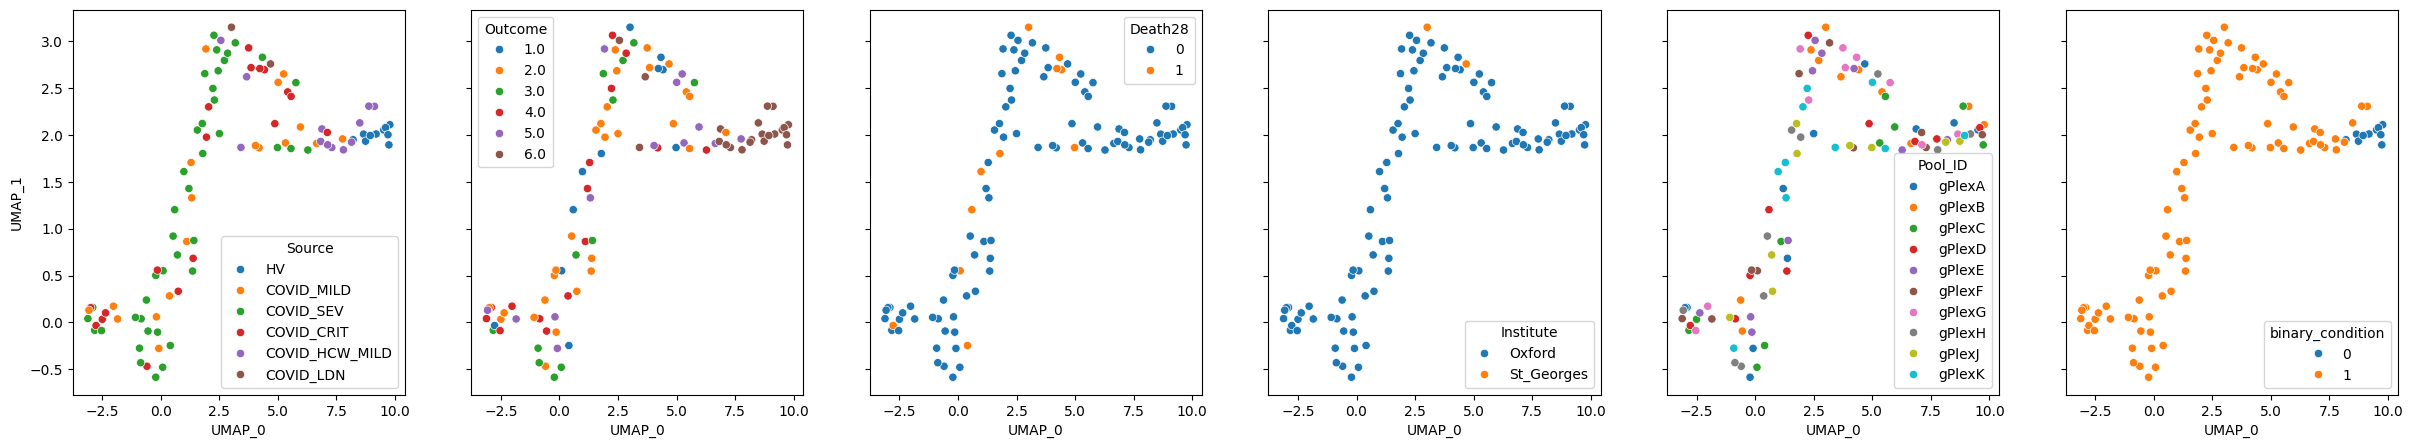

In [14]:
pascient.plot_embedding(method="UMAP", metadata_cols=samples_metadata_cols, continuous_palette="tab10");

## Binary prediction

Since `binary_condition` was specified as a label during training, PaSCient can predict it directly without additional fine-tuning.

In [15]:
pascient_prediction = pascient.predict("binary_condition")
pascient_prediction

/ictstr01/groups/luckylab/workspace/vladimir.shitov/patpy/src/patpy/tl/supervised.py:1690: UserWarning: Using data from adata.layers['X_raw_counts']
  X = self._get_data()


,prob_0,prob_1,binary_condition_pred
S00109-Ja001E-PBCa,0.064021,0.935979,1
S00112-Ja003E-PBCa,0.054047,0.945953,1
S00005-Ja005E-PBCa,0.057151,0.942849,1
S00061-Ja003E-PBCa,0.037848,0.962152,1
S00056-Ja003E-PBCa,0.051078,0.948922,1
...,...,...,...
S00076-Ja001E-PBCa,0.073532,0.926468,1
S00072-Ja001E-PBCa,0.079654,0.920346,1
S00065-Ja003E-PBCa,0.059482,0.940518,1
S00048-Ja003E-PBCa,0.061706,0.938294,1


In [16]:
y_true = metadata.loc[pascient_prediction.index, "binary_condition"]
print(classification_report(y_true, pascient_prediction["binary_condition_pred"]))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        10
           1       0.90      1.00      0.95        91

    accuracy                           0.90       101
   macro avg       0.45      0.50      0.47       101
weighted avg       0.81      0.90      0.85       101



/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to

## Multiclass prediction

We can also fine-tune for the multiclass `Source` label.

In [17]:
metadata["Source"].value_counts()

Source
COVID_SEV         41
COVID_MILD        18
COVID_CRIT        18
COVID_HCW_MILD    12
HV                10
COVID_LDN          2
Name: count, dtype: int64

In [18]:
pascient.fine_tune("Source", tasks="classification")

/ictstr01/groups/luckylab/workspace/vladimir.shitov/patpy/src/patpy/tl/supervised.py:1690: UserWarning: Using data from adata.layers['X_raw_counts']
  X = self._get_data()


GPU available: True (cuda), used: True


TPU available: False, using: 0 TPU cores


💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [MIG-52c735f7-a582-5461-a060-43b869010675]


...

/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/lightning/pytorch/utilities/_
pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and 
treespec.is_leaf()` instead.

/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/lightning/pytorch/trainer/con
nectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider 
increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.

/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/lightning/pytorch/trainer/con
nectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. 
Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve 
performance.

/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/lightning/pytorch/loops/fit_l
oop.py:534: Found 17 module(s) in eval mode at the start of training. This may lead to unexpected behavior during 
training. If this is intentional, you can ignore this warning.

`Trainer.fit` stopped: `max_epochs=4` reached.


In [19]:
pascient_source_prediction = pascient.predict("Source")
pascient_source_prediction

,prob_COVID_CRIT,prob_COVID_HCW_MILD,prob_COVID_LDN,prob_COVID_MILD,prob_COVID_SEV,prob_HV,Source_pred
S00109-Ja001E-PBCa,0.216434,0.085500,0.010516,0.150212,0.506198,0.031140,COVID_SEV
S00112-Ja003E-PBCa,0.219337,0.084208,0.010287,0.150565,0.505148,0.030455,COVID_SEV
S00005-Ja005E-PBCa,0.223977,0.083785,0.010268,0.143777,0.508372,0.029822,COVID_SEV
S00061-Ja003E-PBCa,0.211482,0.067916,0.006508,0.139969,0.552922,0.021203,COVID_SEV
S00056-Ja003E-PBCa,0.221930,0.081710,0.009754,0.146301,0.511630,0.028673,COVID_SEV
...,...,...,...,...,...,...,...
S00076-Ja001E-PBCa,0.216756,0.104331,0.015210,0.165878,0.454249,0.043575,COVID_SEV
S00072-Ja001E-PBCa,0.216502,0.111414,0.018783,0.170740,0.431625,0.050936,COVID_SEV
S00065-Ja003E-PBCa,0.221151,0.088709,0.011390,0.151118,0.494472,0.033159,COVID_SEV
S00048-Ja003E-PBCa,0.218859,0.080883,0.009970,0.147410,0.513702,0.029176,COVID_SEV


In [20]:
source_true = metadata.loc[pascient_source_prediction.index, "Source"]
print(classification_report(source_true, pascient_source_prediction["Source_pred"]))

                precision    recall  f1-score   support

    COVID_CRIT       0.00      0.00      0.00        18
COVID_HCW_MILD       0.00      0.00      0.00        12
     COVID_LDN       0.00      0.00      0.00         2
    COVID_MILD       0.00      0.00      0.00        18
     COVID_SEV       0.41      1.00      0.58        41
            HV       0.00      0.00      0.00        10

      accuracy                           0.41       101
     macro avg       0.07      0.17      0.10       101
  weighted avg       0.16      0.41      0.23       101



/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to

### Cell importance

PaSCient can compute per-cell importance scores to identify which cells contribute most to sample-level representations.

> **Note:** By default, `get_cell_importance()` uses Integrated Gradients (IG) from the PaSCient paper when [captum](https://captum.ai/) is installed, and falls back to cosine similarity between cell and sample embeddings otherwise.

In [21]:
cell_importance = pascient.get_cell_importance(target=1)
importance_scores = cell_importance.iloc[:, 0]
print(f"Importance scores: min={importance_scores.min():.4f}, max={importance_scores.max():.4f}, mean={importance_scores.mean():.4f}")

### Cell importance by disease severity and cell type

Visualize the distribution of cell importance scores. Since most scores are near zero with a long tail of important cells, we use strip plots with log-scaled y-axis for better visibility.

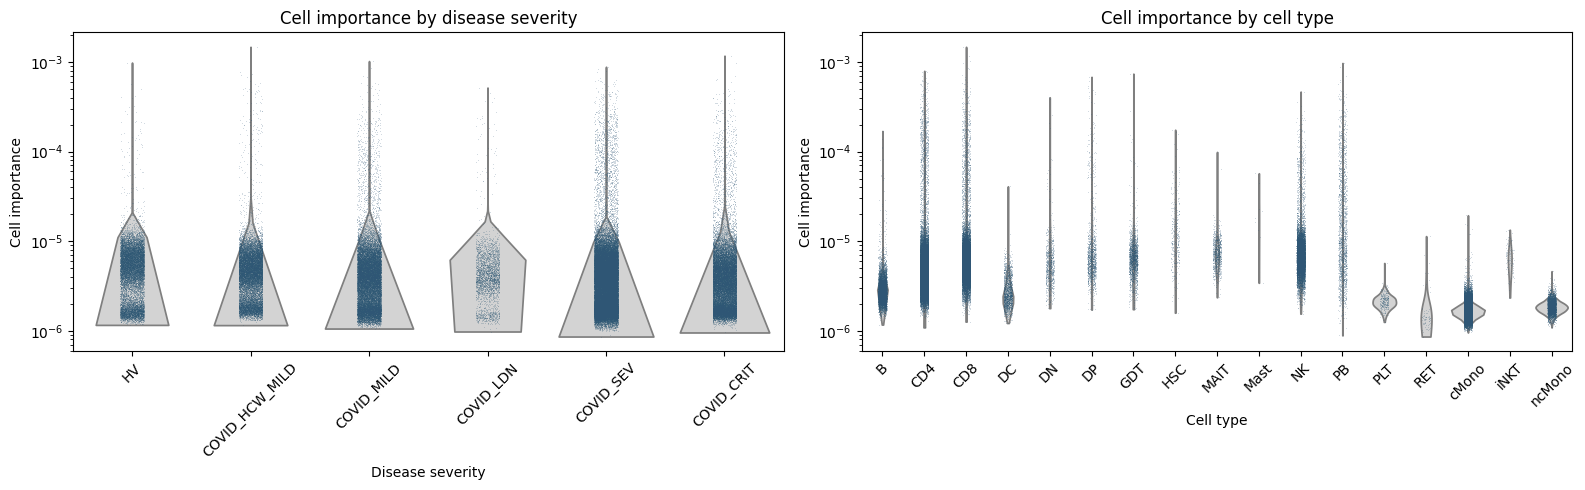

In [22]:
import seaborn as sns

# Build dataframe with importance scores and metadata
cell_imp_df = pd.DataFrame({
    "importance": importance_scores,
    "Source": adata.obs["Source"].values,
    "cell_type": adata.obs[cell_type_key].values,
}, index=adata.obs_names)

severity_order = ["HV", "COVID_HCW_MILD", "COVID_MILD", "COVID_LDN", "COVID_SEV", "COVID_CRIT"]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Filter to nonzero for log-scale strip plot
nonzero = cell_imp_df[cell_imp_df["importance"] > 0]

# By disease severity
ax = axes[0]
sns.violinplot(data=nonzero, x="Source", y="importance", order=severity_order,
               cut=0, inner=None, color="lightgrey", ax=ax)
sns.stripplot(data=nonzero, x="Source", y="importance", order=severity_order,
              size=0.5, alpha=0.3, jitter=True, ax=ax)
ax.set_yscale("log")
ax.set_xlabel("Disease severity")
ax.set_ylabel("Cell importance")
ax.set_title("Cell importance by disease severity")
ax.tick_params(axis="x", rotation=45)

# By cell type
ax = axes[1]
sns.violinplot(data=nonzero, x="cell_type", y="importance",
               cut=0, inner=None, color="lightgrey", ax=ax)
sns.stripplot(data=nonzero, x="cell_type", y="importance",
              size=0.5, alpha=0.3, jitter=True, ax=ax)
ax.set_yscale("log")
ax.set_xlabel("Cell type")
ax.set_ylabel("Cell importance")
ax.set_title("Cell importance by cell type")
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

### Summary statistics

Descriptive statistics of cell importance scores grouped by disease severity and cell type.

In [23]:
print("=== Cell importance by disease severity ===")
cell_imp_df.groupby("Source")["importance"].describe().loc[severity_order].round(6)

=== Cell importance by disease severity ===


/localscratch/vladimir.shitov/ipykernel_2539316/745167923.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cell_imp_df.groupby("Source")["importance"].describe().loc[severity_order].round(6)


,count,mean,std,min,25%,50%,75%,max
Source,,,,,,,,
HV,87204.0,0.000001,0.000006,0.0,0.0,0.0,0.000000,0.000984
COVID_HCW_MILD,84359.0,0.000001,0.000012,0.0,0.0,0.0,0.000000,0.001475
COVID_MILD,107376.0,0.000002,0.000012,0.0,0.0,0.0,0.000001,0.001023
COVID_LDN,14832.0,0.000001,0.000011,0.0,0.0,0.0,0.000000,0.000517
COVID_SEV,230343.0,0.000002,0.000012,0.0,0.0,0.0,0.000001,0.000883
COVID_CRIT,87620.0,0.000002,0.000013,0.0,0.0,0.0,0.000002,0.001174


In [24]:
print("=== Cell importance by cell type ===")
cell_imp_df.groupby("cell_type")["importance"].describe().round(6)

=== Cell importance by cell type ===


/localscratch/vladimir.shitov/ipykernel_2539316/2882895137.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cell_imp_df.groupby("cell_type")["importance"].describe().round(6)


,count,mean,std,min,25%,50%,75%,max
cell_type,,,,,,,,
B,37103.0,0.000001,0.000002,0.0,0.0,0.0,0.000002,0.000170
CD4,218353.0,0.000002,0.000012,0.0,0.0,0.0,0.000000,0.000795
CD8,87562.0,0.000003,0.000018,0.0,0.0,0.0,0.000000,0.001475
DC,7287.0,0.000001,0.000001,0.0,0.0,0.0,0.000000,0.000041
DN,3426.0,0.000002,0.000012,0.0,0.0,0.0,0.000000,0.000403
DP,5354.0,0.000004,0.000028,0.0,0.0,0.0,0.000000,0.000681
GDT,7935.0,0.000002,0.000010,0.0,0.0,0.0,0.000000,0.000739
HSC,1124.0,0.000005,0.000014,0.0,0.0,0.0,0.000006,0.000175
MAIT,3977.0,0.000002,0.000004,0.0,0.0,0.0,0.000000,0.000099


In this tutorial you learned how to train PaSCient from scratch, extract sample representations, evaluate them, make binary and multiclass predictions, and compute cell importance scores with `patpy`.